In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 20

In [3]:
def h(pt1, pt2, startPoint, lam, pref):
    r1 = pt1 - startPoint + 1.5
    r2 = pt2 - startPoint + 1.5
    r1 %= 1
    r2 %= 1
    r1 -= 0.5
    r2 -= 0.5
    d = r2 - r1
    return pref * (r1[0] + r2[0]) * d[1] - lam * np.sqrt(np.sum(d**2))

In [4]:
def g12(pt1, pt2, startPoint, lam, pref):
    r1 = pt1 - startPoint + 1.5
    r2 = pt2 - startPoint + 1.5
    r1 %= 1
    r2 %= 1
    r1 -= 0.5
    r2 -= 0.5
    d = pt2 - pt1 + 1.5
    d %= 1
    d -= 0.5
    lambd = lam * d / np.sqrt(np.sum(d**2))
    g1x = pref * d[1] + lambd[0]
    g1y = -pref * (r1[0] + r2[0]) + lambd[1]
    g2x = pref * d[1] - lambd[0]
    g2y = pref * (r1[0] + r2[0]) - lambd[1]
    return np.array([g1x, g1y]), np.array([g2x, g2y])

<Figure size 640x480 with 0 Axes>

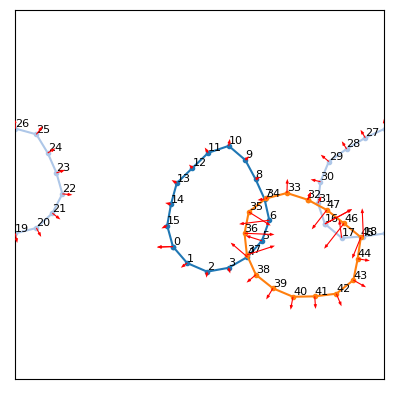

In [8]:
lam = 0.0
pref = 1
numPolygons = 3
n = 16
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 0
phi = 0.2
kappa = 3.65
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons, n, kappa = kappa, phi = phi)
#modelDir = "minCheckpointRestart2/" + str(np.max(np.array(os.listdir("minCheckpointRestart2")).astype(int)))
#m.loadModel(modelDir)
plt.clf()
# Works fine
m.setMaxEdgeLength()
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0.01)
m.updateContacts()
m.updateOutersections()
overlapArea, force = m.functional(h, g12 = g12, lam = lam, pref = pref)
force0 = m.getConstrainedForce(force)
positions0 = m.getPositions()# Now you have dA, can you draw arrows on the vertices?
artists = m.draw(forces = force0, arrowColor = 'r', numbering = True)

In [9]:
overlapArea

-0.0020791840822083976

In [6]:
si = (m.getIntersections() >> 48) & 0xFFFF
sj = (m.getIntersections() >> 32) & 0xFFFF
j = (m.getIntersections() >> 16) & 0xFFFF
i = (m.getIntersections()) & 0xFFFF

In [7]:
startPos = m.getPositions()
m.minimizeGD(h = h, g12 = g12, lam = lam, pref = pref, maxSteps = maxSteps, dt = 0.001, progressBar = True, checkpointDir = "forceTestingCUDACOMP2", checkpointFreq = 1)
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0.01)
m.updateContacts()
m.updatePlayers()
overlapArea, force = m.functional(h = h, g12 = g12, lam = lam, pref = pref)
force0 = m.getConstrainedForce(force)
positions0 = m.getPositions()

Processing:   0%|                                    | 0/20 [00:00<?, ?it/s]


Exception: Packing exists. Not saving. To save over this file, set kwarg overwrite = True

In [ ]:
artists = m.draw(forces = force0, arrowColor = 'r')

In [ ]:
np.max(np.abs(force0))

In [ ]:
#m.loadModel("squishsquish10v6")

In [ ]:
#m.getPositions()

In [ ]:
m.saveModel("squishsquish10v7")

In [ ]:
m.updateAreas()
areas = m.getAreas()
print(areas, np.std(areas), np.std(areas) / np.mean(areas))

In [ ]:
# It only drifted by about 1% which is pretty remarkable actually

In [ ]:
edges = m.getEdgeLengths()
l0 = np.sqrt(phi / m.getNumPolygons()) * kappa / m.getnArray()
edges = (edges.reshape(len(edges) // 32, 32).T / l0).T
print(np.std(edges, axis = 1) / np.mean(edges, axis = 1))